#                     BRCA1 Gene Analysis

Fetching and analyzing the BRCA1 gene from NCBI database.
BRCA1 is associated with breast and ovarian cancer risk.


In [1]:
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
import matplotlib.pyplot as plt

In [2]:
Entrez.email = "rajat@email.com"

handle = Entrez.efetch(
    db="nucleotide",
    id="NM_007294",
    rettype="fasta",
    retmode="text"
)
record = SeqIO.read(handle, "fasta")
handle.close()

print(record.id)
print(record.description)
print(f"Length: {len(record.seq)} bp")

NM_007294.4
NM_007294.4 Homo sapiens BRCA1 DNA repair associated (BRCA1), transcript variant 1, mRNA
Length: 7088 bp


In [3]:
dna = record.seq
rna = dna.transcribe()
protein = dna.translate()

print("DNA (first 60):", dna[:60])
print("RNA (first 60):", rna[:60])
print("Protein (first 30):", protein[:30])

DNA (first 60): GCTGAGACTTCCTGGACGGGGGACAGGCTGTGGGGTTTCTCAGATAACTGGGCCCCTGCG
RNA (first 60): GCUGAGACUUCCUGGACGGGGGACAGGCUGUGGGGUUUCUCAGAUAACUGGGCCCCUGCG
Protein (first 30): AETSWTGDRLWGFSDNWAPALRRPSPSALG


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\Bio\Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [4]:
gc = gc_fraction(dna) * 100
print(f"GC Content: {gc:.2f}%")

if gc > 60:
    print("Stability: High")
elif gc > 40:
    print("Stability: Normal")
else:
    print("Stability: Low")

dna_str = str(dna)
for base in ["A", "T", "G", "C"]:
    count = dna_str.count(base)
    print(f"{base}: {count} ({count/len(dna_str)*100:.1f}%)")

GC Content: 41.77%
Stability: Normal
A: 2368 (33.4%)
T: 1759 (24.8%)
G: 1585 (22.4%)
C: 1376 (19.4%)


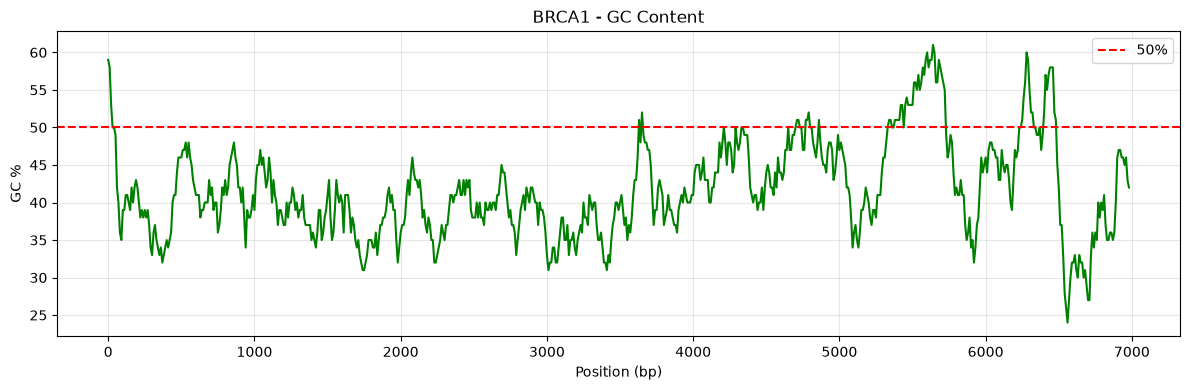

In [5]:
window = 100
gc_vals = []
positions = []

for i in range(0, len(dna_str) - window, 10):
    chunk = dna_str[i:i+window]
    gc_vals.append((chunk.count("G") + chunk.count("C")) / window * 100)
    positions.append(i)

plt.figure(figsize=(12, 4))
plt.plot(positions, gc_vals, color="green", linewidth=1.5)
plt.axhline(y=50, color="red", linestyle="--", label="50%")
plt.title("BRCA1 - GC Content")
plt.xlabel("Position (bp)")
plt.ylabel("GC %")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("BRCA1_gc_plot.png", dpi=300)
plt.show()

In [6]:
with open("BRCA1_report.txt", "w") as f:
    f.write(f"Gene: {record.id}\n")
    f.write(f"Length: {len(dna)} bp\n")
    f.write(f"GC Content: {gc:.2f}%\n")
    f.write(f"DNA: {dna[:100]}\n")
    f.write(f"RNA: {rna[:100]}\n")
    f.write(f"Protein: {protein[:50]}\n")

print("Report saved.")

Report saved.
